In [2]:
import pandas as pd
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    roc_auc_score, roc_curve, confusion_matrix
)
from sklearn.tree import plot_tree
from sklearn.utils import resample



In [ ]:
project_root = Path().resolve().parent
df = pd.read_csv(project_root / "data/cleaned.csv", index_col=0)

df["target"] = (
    df['10'] >
    df['0']
    ).astype('int8')
df["target"].sum()


num_cols = df.select_dtypes(include="number").columns
num_cols = [c for c in num_cols if not (str(c).isdigit() and 0 <= int(c) <= 750)]
df_numeric = df[num_cols]
df_numeric = df_numeric.drop(columns="transaction_month")

                Modell  Accuracy   ROC AUC  Precision    Recall
0        Random Forest  0.606876  0.643066   0.596635  0.962058
1  Logistic Regression  0.571854  0.540847   0.572525  0.988028


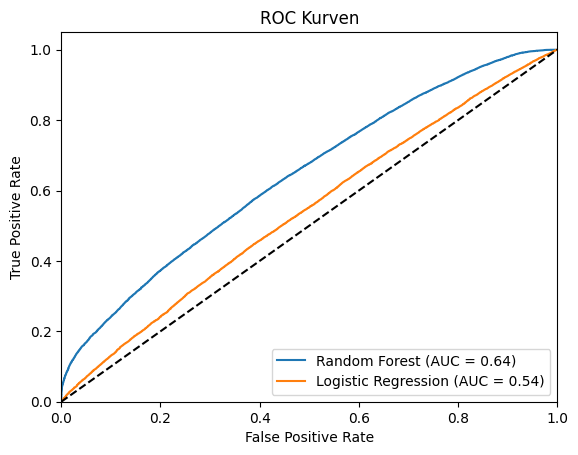

In [ ]:
y = df_numeric['target']
x_columns = [col for col in df_numeric.columns if col != "target"]
X = df_numeric[x_columns]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

y_train_enc = np.asarray(y_train).astype(int)
neg, pos = np.bincount(y_train_enc)
scale_pos_weight = (neg / pos) if pos > 0 else 1.0

models = {
    "Random Forest": RandomForestClassifier(n_estimators=1200,
                                            max_depth=10,
                                            max_features="sqrt",
                                            min_samples_split=20,
                                            min_samples_leaf=10,
                                            class_weight=None,
                                            bootstrap=True,
                                            oob_score=True,
                                            n_jobs=-1,
                                            random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=10000),
}

results = []

for model_name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_pred_prob = model.predict_proba(X_test)[:, 1]
    accuracy = accuracy_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_prob)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
    results.append({
        "Modell": model_name,
        "Accuracy": accuracy,
        "ROC AUC": roc_auc,
        "Precision": precision,
        "Recall": recall
    })
    
    plt.plot(fpr, tpr, label=f'{model_name} (AUC = {roc_auc:.2f})')

results_df = pd.DataFrame(results)
print(results_df)

plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Kurven')
plt.legend(loc="lower right")
plt.show()

for model_name, model in models.items():
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    
    cm = confusion_matrix(y_test, y_pred)

    df_cm = pd.DataFrame(cm, index=['Actual: target=0', 'Actual: target=1'], 
                         columns=['Predicted: target=0', 'Predicted: target=1'])
    
    cm_values = df_cm.values.astype('float')
    cm_normalized = cm_values / cm_values.sum(axis=1)[:, np.newaxis]
    
    df_cm_normalized = pd.DataFrame(cm_normalized, index=df_cm.index, columns=df_cm.columns)
    
    plt.figure(figsize=(6, 4))
    heatmap = sns.heatmap(df_cm_normalized, annot=True, fmt='.2f', cmap="Blues")
    
    heatmap.yaxis.set_ticklabels(heatmap.yaxis.get_ticklabels(), rotation=0, ha='right')
    heatmap.xaxis.set_ticklabels(heatmap.xaxis.get_ticklabels(), rotation=45, ha='right')
    
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.title(f'Normalized Confusion Matrix - {model_name}')
    plt.show()
    
feature_importances = pd.DataFrame()

if "Logistic Regression" in models:
    log_reg = models["Logistic Regression"]
    log_reg.fit(X_train, y_train)
    feature_importances["Logistic Regression"] = np.abs(log_reg.coef_[0]) 

if "Random Forest" in models:
    rf = models["Random Forest"]
    rf.fit(X_train, y_train)
    feature_importances["Random Forest"] = rf.feature_importances_

feature_importances.index = X_train.columns

feature_importances = feature_importances.sort_values(by="Logistic Regression", ascending=False)
print("Feature importance for each model:")
print(feature_importances)


In [ ]:
log_reg = models["Logistic Regression"].fit(X_train, y_train)
coefs = pd.Series(log_reg.coef_[0], index=X_train.columns)
or_ = np.exp(coefs)

or_table = pd.DataFrame({
    "Koeffizient": coefs,
    "Odds Ratio": or_,
})

or_table["percent chance target/not target"] = np.where(
    or_table["Odds Ratio"]>=1,
    (or_table["Odds Ratio"]-1)*100,
    -(1-or_table["Odds Ratio"])*100
).round(1)

or_table = or_table.reindex(or_table["Koeffizient"].abs().sort_values(ascending=False).index)
or_table

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

y_train_enc = np.asarray(y_train).astype(int)
neg, pos = np.bincount(y_train_enc)
scale_pos_weight = (neg / pos) if pos > 0 else 1.0

models = {
    "Random Forest": RandomForestClassifier(n_estimators=1200,
                                            max_depth=10,
                                            max_features="sqrt",
                                            min_samples_split=20,
                                            min_samples_leaf=10,
                                            class_weight=None,
                                            bootstrap=True,
                                            oob_score=True,
                                            n_jobs=-1,
                                            random_state=42),
}

results = []

for model_name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_pred_prob = model.predict_proba(X_test)[:, 1]

fig, ax = plt.subplots(figsize=(10,10),dpi=300,)
fn = list(X_train.columns)
cn = [str(cls) for cls in np.unique(y_train)]

estimator = model.estimators_[0]

plot_tree(estimator,
feature_names=fn,
class_names=cn,
filled=True,
fontsize=3,
ax=ax)

fig.savefig("baum_plot.png", dpi=300, bbox_inches='tight')

plt.show()
